In [1]:
import numpy as np
from enum import IntEnum
from dataclasses import dataclass
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class CellType(IntEnum):
    MONTH = 0
    DAY = 1
    WALL = 2

@dataclass
class Cell:
    label: str
    cell_type: CellType
    occupied: bool = False
    piece_id: str = None

In [3]:
def render_board(board, ax=None):
    H, W = len(board), len(board[0])

    if ax is None:
        fig, ax = plt.subplots(figsize=(W, H))

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")

    ax.add_patch(
        patches.Rectangle(
            (0, 0), W, H,
            facecolor="#D2B48C",  # tan / wood
            zorder=0
        )
    )

    for r in range(H):
        for c in range(W):
            cell = board[r][c]

            if cell.cell_type.name == "WALL":
                continue

            if cell.occupied and cell.piece_id:
                piece_color = PUZZLE_PIECES[cell.piece_id].color  # Use the piece's color
                face = piece_color
                edge = "#5D4037"
                lw = 1.5
            elif cell.cell_type.name == "MONTH":
                face = "#FFE082"  # light highlight
                edge = "#C9A227"
                lw = 1.0
            else:  # DAY
                face = "#FFF8E1"
                edge = "#D7CCC8"
                lw = 0.8

            rect = patches.FancyBboxPatch(
                (c + 0.05, r + 0.05),
                0.9, 0.9,
                boxstyle="round,pad=0.02,rounding_size=0.08",
                facecolor=face,
                edgecolor=edge,
                linewidth=lw,
                zorder=2
            )
            ax.add_patch(rect)

            ax.text(
                c + 0.5, r + 0.55,
                cell.label,
                ha="center", va="center",
                fontsize=10,
                color="#3E2723",
                fontweight="bold",
                zorder=3
            )

    return ax

In [4]:
# array of objects of class Cell
BASE_BOARD = [
    [Cell("JAN", CellType.MONTH), Cell("FEB", CellType.MONTH), Cell("MAR", CellType.MONTH),
     Cell("APR", CellType.MONTH), Cell("MAY", CellType.MONTH), Cell("JUN", CellType.MONTH),
     Cell("WALL", CellType.WALL)],

    [Cell("JUL", CellType.MONTH), Cell("AUG", CellType.MONTH), Cell("SEP", CellType.MONTH),
     Cell("OCT", CellType.MONTH), Cell("NOV", CellType.MONTH), Cell("DEC", CellType.MONTH),
     Cell("WALL", CellType.WALL)],

    [Cell("1", CellType.DAY), Cell("2", CellType.DAY), Cell("3", CellType.DAY),
     Cell("4", CellType.DAY), Cell("5", CellType.DAY), Cell("6", CellType.DAY),
     Cell("7", CellType.DAY)],

    [Cell("8", CellType.DAY), Cell("9", CellType.DAY), Cell("10", CellType.DAY),
     Cell("11", CellType.DAY), Cell("12", CellType.DAY), Cell("13", CellType.DAY),
     Cell("14", CellType.DAY)],

    [Cell("15", CellType.DAY), Cell("16", CellType.DAY), Cell("17", CellType.DAY),
     Cell("18", CellType.DAY), Cell("19", CellType.DAY), Cell("20", CellType.DAY),
     Cell("21", CellType.DAY)],

    [Cell("22", CellType.DAY), Cell("23", CellType.DAY), Cell("24", CellType.DAY),
     Cell("25", CellType.DAY), Cell("26", CellType.DAY), Cell("27", CellType.DAY),
     Cell("28", CellType.DAY)],

    [Cell("29", CellType.DAY), Cell("30", CellType.DAY), Cell("31", CellType.DAY),
     Cell("WALL", CellType.WALL), Cell("WALL", CellType.WALL),
     Cell("WALL", CellType.WALL), Cell("WALL", CellType.WALL)],
]

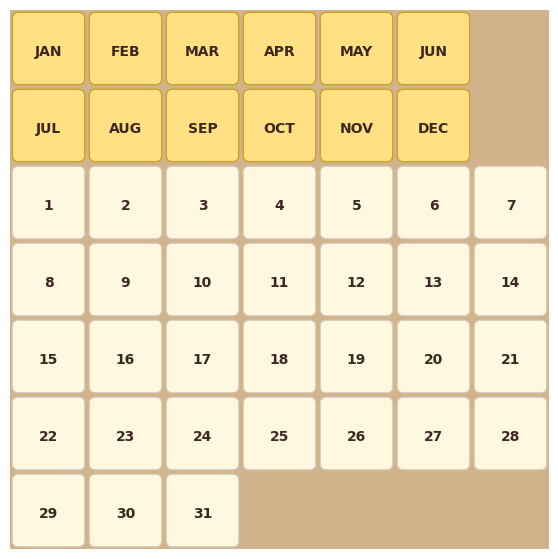

In [5]:
render_board(BASE_BOARD)
plt.show()

In [6]:
def unique_orientations(mask):
    import numpy as np

    orientations = []
    seen = set()

    for flip in [False, True]:
        m = np.fliplr(mask) if flip else mask

        for k in range(4):
            rot = np.rot90(m, k)
            key = (rot.shape, rot.tobytes())  

            if key not in seen:
                seen.add(key)
                orientations.append(rot)

    return orientations


In [7]:
class PuzzlePiece:
    def __init__(self, name, mask, color):
        self.name = name
        self.mask = mask
        self.orientations = unique_orientations(mask)
        self.color = color


In [8]:
WOOD_COLORS= [
    "#E6D5C3",  # very light maple
    "#D7C2A8",  # light maple
    "#C9AD8F",  # honey oak
    "#B8956F",  # oak
    "#A07A55",  # warm teak
    "#8B6344",  # medium walnut
    "#6F4B34",  # dark walnut
    "#543626",  # very dark walnut
]
PUZZLE_PIECES = {
    "R": PuzzlePiece(
        "R",
        np.array([
            [1, 1],
            [1, 1],
            [1, 1],
        ]),
        WOOD_COLORS[0],
    ),

    "L3": PuzzlePiece(
        "L3",
        np.array([
            [1, 0, 0],
            [1, 0, 0],
            [1, 1, 1],
        ]),
        WOOD_COLORS[1],
    ),

    "L4": PuzzlePiece(
        "L4",
        np.array([
            [1, 0],
            [1, 0],
            [1, 0],
            [1, 1],
        ]),
        WOOD_COLORS[2],
    ),

    "Z": PuzzlePiece(
        "Z",
        np.array([
            [1, 0, 0],
            [1, 1, 1],
            [0, 0, 1]
        ]),
        WOOD_COLORS[3],
    ),

    "N": PuzzlePiece(
        "N",
        np.array([
            [0, 1],
            [0, 1],
            [1, 1],
            [1, 0],
        ]),
        WOOD_COLORS[4],
    ),
    
    "T": PuzzlePiece(
        "T",
        np.array([
            [0, 1, 0],
            [1, 1, 0],
            [0, 1, 0],
            [0, 1, 0],
        ]),
        WOOD_COLORS[5],
    ),

    "P": PuzzlePiece(
        "P",
        np.array([
            [1, 1],
            [1, 1],
            [1, 0],
        ]),
        WOOD_COLORS[6],
    ),

    "U": PuzzlePiece(
        "U",
        np.array([
            [1, 0, 1],
            [1, 1, 1],
        ]),
        WOOD_COLORS[7],
    ),
}


In [9]:
for name, piece in PUZZLE_PIECES.items():
    print(name, "orientations:", len(piece.orientations))


R orientations: 2
L3 orientations: 4
L4 orientations: 8
Z orientations: 4
N orientations: 8
T orientations: 8
P orientations: 8
U orientations: 4


In [10]:
def place_piece(board, mask, row, col, piece_id):
    ph, pw = mask.shape
    for i in range(ph):
        for j in range(pw):
            if mask[i, j] == 1:
                board[row + i][col + j].occupied = True
                board[row + i][col + j].piece_id = piece_id  # Set the piece_id

def can_place(board, mask, row, col):
    H, W = len(board), len(board[0])
    ph, pw = mask.shape

    for i in range(ph):
        for j in range(pw):
            if mask[i, j] == 0:
                continue

            r, c = row + i, col + j

            if r < 0 or c < 0 or r >= H or c >= W:
                return False

            cell = board[r][c]

            if cell.cell_type.name == "WALL" or cell.occupied:
                return False

    return True

def clear_board(board):
    for row in board:
        for cell in row:
            cell.occupied = False


In [11]:
clear_board(BASE_BOARD)
piece = PUZZLE_PIECES["L3"]
mask = piece.orientations[0]

row, col = 4, 0

if can_place(BASE_BOARD, mask, row, col):
    place_piece(BASE_BOARD, mask, row, col, "L3")
    print("Placed successfully")
else:
    print("Invalid placement")

piece = PUZZLE_PIECES["U"]
mask = piece.orientations[0]

row, col = 4, 1

if can_place(BASE_BOARD, mask, row, col):
    place_piece(BASE_BOARD, mask, row, col, "U")
    print("Placed successfully")
else:
    print("Invalid placement")

Placed successfully
Placed successfully


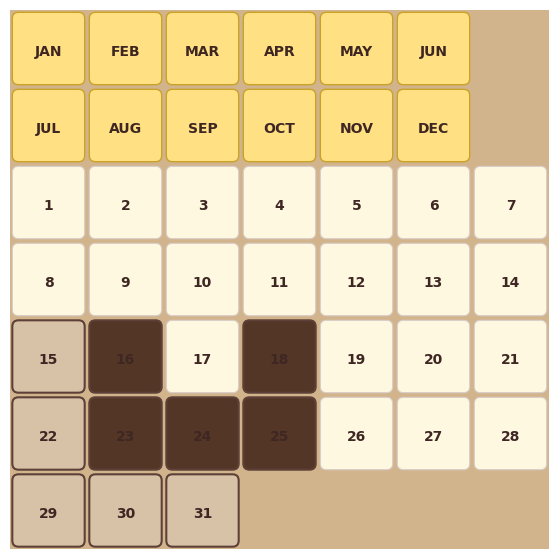

In [12]:
render_board(BASE_BOARD)
plt.show()